# 6.3.- Embeddings y representaciones densas

Los métodos clásicos como **Bag of Words** o **TF–IDF** tratan las palabras como entidades independientes,
sin captar su **significado** ni su **relación semántica**.

Los **embeddings** son representaciones vectoriales que ubican cada palabra en un espacio continuo de dimensiones,
de forma que **palabras con significados similares estén cerca entre sí**.

En este notebook aprenderás a:

1. Crear embeddings con Keras (`Embedding` layer).  
2. Visualizar relaciones semánticas entre palabras.  
3. Usar embeddings **preentrenados** (Word2Vec o GloVe).  
4. Calcular similitud semántica con distancia coseno.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

plt.rcParams['figure.figsize'] = (12, 6)

## Embeddings básicos con Keras

La capa `Embedding` transforma enteros (que representan palabras) en vectores densos de tamaño fijo.

Por ejemplo, si tenemos un vocabulario de 10 palabras, cada palabra puede representarse por un vector de 4 dimensiones.

Durante el entrenamiento, la red **aprende** qué palabras deben tener representaciones similares.

In [4]:
# Ejemplo: vocabulario de 10 palabras, cada una representada en 4 dimensiones
model = Sequential([
    Embedding(input_dim=10, output_dim=4, input_length=5)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Visualización de embeddings aleatorios

Antes de entrenar, los embeddings son vectores inicializados aleatoriamente.  
Vamos a generar algunos valores y reducir sus dimensiones con PCA para visualizarlos.

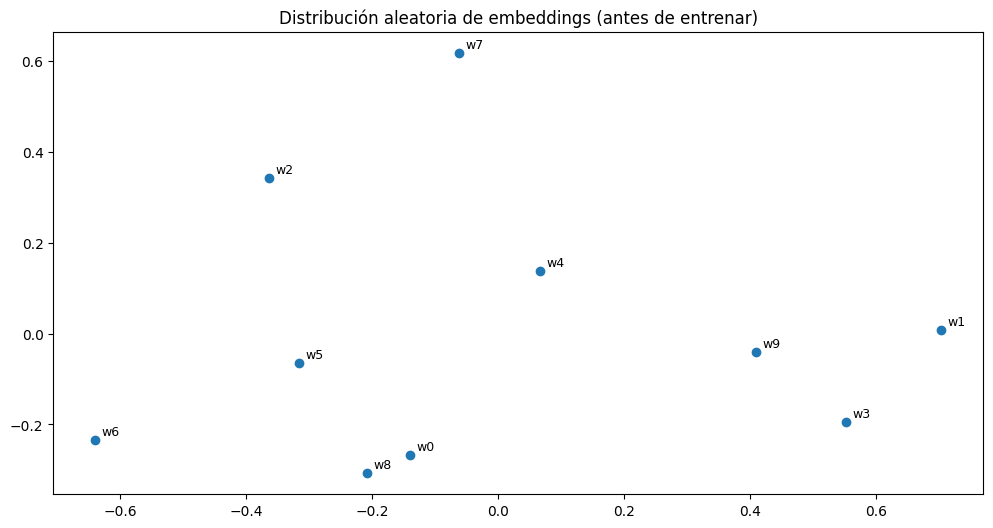

In [6]:
# Simular embeddings para 10 palabras (4 dimensiones)
np.random.seed(33)
embeddings = np.random.rand(10, 4)

# Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Graficar
plt.scatter(reduced[:, 0], reduced[:, 1])
for i in range(10):
    plt.text(reduced[i, 0]+0.01, reduced[i, 1]+0.01, f"w{i}", fontsize=9)
plt.title("Distribución aleatoria de embeddings (antes de entrenar)")
plt.show()

## Embeddings preentrenados (Word2Vec / GloVe)

Entrenar embeddings desde cero requiere millones de textos.
Por eso usamos **modelos preentrenados** que ya han aprendido relaciones semánticas.

Ejemplo: Word2Vec, GloVe o FastText.
A continuación, cargaremos un modelo preentrenado pequeño usando `gensim`.

In [10]:
# Cargar modelo preentrenado (ejemplo: GloVe o Google News Word2Vec)
# Este modelo es muy grande (~1.5 GB). Para demostración, usaremos el modelo reducido de gensim:
from gensim.downloader import load
model = load("glove-wiki-gigaword-50")  # 50 dimensiones

# Ejemplo de palabras similares
model.most_similar("king", topn=5)

[('prince', 0.8236179351806641),
 ('queen', 0.7839043140411377),
 ('ii', 0.7746230363845825),
 ('emperor', 0.7736247777938843),
 ('son', 0.766719400882721)]

## Similitud semántica y distancia coseno

Podemos medir qué tan similares son dos palabras calculando el **coseno del ángulo** entre sus vectores.

Cuanto más cercano a 1, mayor similitud semántica.

In [8]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Ejemplo: comparar "king" y "queen"
v_king = model["king"]
v_queen = model["queen"]
v_table = model["table"]

print("Similitud (king, queen):", round(cosine_similarity(v_king, v_queen), 3))
print("Similitud (king, table):", round(cosine_similarity(v_king, v_table), 3))

Similitud (king, queen): 0.784
Similitud (king, table): 0.285


## Visualización de relaciones semánticas

Podemos representar palabras relacionadas en un plano 2D.
Las palabras con significados similares deben aparecer más cerca unas de otras.

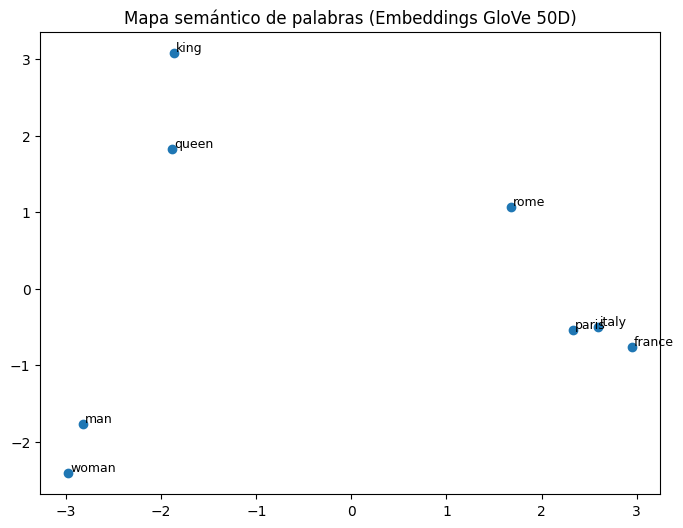

In [9]:
# Seleccionar palabras relacionadas
palabras = ["king", "queen", "man", "woman", "paris", "france", "rome", "italy"]

# Obtener sus vectores
vectors = np.array([model[w] for w in palabras])

# Reducir a 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i, word in enumerate(palabras):
    plt.text(coords[i, 0]+0.02, coords[i, 1]+0.02, word, fontsize=9)

plt.title("Mapa semántico de palabras (Embeddings GloVe 50D)")
plt.show()

## Ejercicio Final

1. Elige 5 palabras de tu interés (en inglés o español).  
2. Usa `model.most_similar("palabra")` para explorar sus relaciones.  
3. Calcula la similitud entre pares de palabras con `cosine_similarity`.  
4. Representa tus palabras en un mapa 2D usando PCA.